# 1 · The one idea behind all of them: policy gradients

**Run every cell top to bottom; there's no code to write.** This notebook runs on a CPU in under a minute.

REINFORCE, PPO, GRPO and (indirectly) DPO all rest on one trick for improving a model when all you can do is *sample* from it and *score* the samples. This notebook shows that trick on the smallest possible problem, where we can also compute the exact answer and check it. The next notebooks apply the exact same thing to an LLM.

The loop every algorithm in this course runs:

In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from rlcourse import viz

viz.figure("rl_loop.svg")

## Reading the loop: one update, by hand

Forget bandits and math for a moment. Say a model answers **"What is 7 × 8?"** and, to keep it tiny, it can only say one of three things: `54`, `56` or `63`. Its current habits (the **policy** π) are:

| answer | 54 | 56 | 63 |
|---|---|---|---|
| π(answer) | 0.30 | 0.40 | 0.30 |

Now walk around the loop once:

1. **Sample.** Ask it 4 times. It says `56`, `54`, `56`, `63`.
2. **Score.** The **reward** is just a grade from a checker: 1 if right, 0 if wrong. Rewards: `1, 0, 1, 0`. Nothing more: a number per answer, computed by plain code, that we can't differentiate through.
3. **Advantage.** "Was this answer *better or worse than usual*?" The **baseline** is what we expected on average (here, the batch's mean reward, 0.5), and the **advantage** is A = reward − baseline: `+0.5, −0.5, +0.5, −0.5`. Positive means "better than typical, do more of this", negative means "worse than typical, do less".
4. **Update.** Change π so that answers with positive A become more likely and answers with negative A less likely, each in proportion to |A|. The loss **−A · log π(answer)** is just the shortest way to tell PyTorch exactly that (details below the plot).

Run the cell to see that single update happen:

sampled   : ['56', '54', '56', '63']
reward    : [1.0, 0.0, 1.0, 0.0]
baseline  : 0.50  (mean reward)
advantage : [0.5, -0.5, 0.5, -0.5]


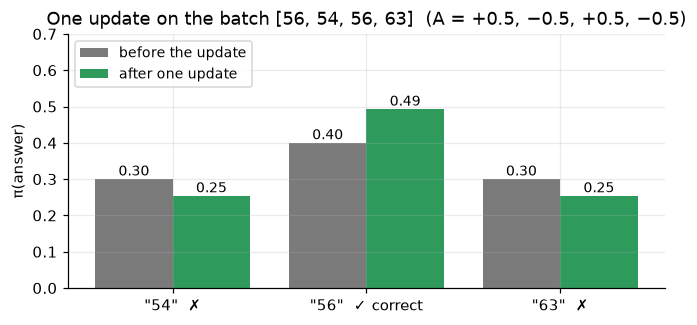

In [2]:
answers = ["54", "56", "63"]
logits = torch.log(torch.tensor([0.30, 0.40, 0.30])).requires_grad_(True)  # the policy's parameters
sampled = torch.tensor([1, 0, 1, 2])  # indices into answers: 56, 54, 56, 63
rewards = torch.tensor([1.0, 0.0, 1.0, 0.0])  # 1 = correct


def one_step(weights, lr=1.0):
    # One gradient step on loss = -mean(weight * log π(sampled answer)). Returns the new π.
    l = logits.detach().clone().requires_grad_(True)
    log_pi = torch.log_softmax(l, -1)[sampled]
    loss = -(weights * log_pi).mean()
    loss.backward()
    with torch.no_grad():
        return torch.softmax(l - lr * l.grad, -1)


baseline = rewards.mean()
advantages = rewards - baseline
print("sampled   :", [answers[i] for i in sampled])
print("reward    :", rewards.tolist())
print(f"baseline  : {baseline:.2f}  (mean reward)")
print("advantage :", advantages.tolist())

before = torch.softmax(logits, -1).detach()
after = one_step(advantages)

fig, ax = plt.subplots(figsize=(7, 3))
x = np.arange(3)
ax.bar(x - 0.2, before, 0.4, color=viz.PALETTE["gray"], label="before the update")
ax.bar(x + 0.2, after, 0.4, color=viz.PALETTE["green"], label="after one update")
for xi, (b, a) in enumerate(zip(before, after)):
    ax.text(xi - 0.2, b + 0.01, f"{b:.2f}", ha="center", fontsize=9)
    ax.text(xi + 0.2, a + 0.01, f"{a:.2f}", ha="center", fontsize=9)
ax.set_xticks(x), ax.set_xticklabels([f'"{a}"' + ("  ✓ correct" if a == "56" else "  ✗") for a in answers])
ax.set_ylabel("π(answer)"), ax.set_ylim(0, 0.7), ax.legend(loc="upper left", fontsize=9)
ax.set_title("One update on the batch [56, 54, 56, 63]  (A = +0.5, −0.5, +0.5, −0.5)")
plt.show()

**What the plot shows:** after one update the correct answer `56` went from 0.40 to about 0.49, and both wrong answers became less likely. Repeat this loop many times and π piles up on `56`. That's all "learning" means here.

(Why bother with the baseline, rather than weighting by the raw reward? In this tiny batch it barely matters. It matters a lot when rewards are noisy or all positive; the "Baselines" section further down shows a case where skipping it makes training lock onto the wrong answer.)

### Why the loss is −A · log π

Read it in pieces:

- **log π(answer)** is the model's log-probability of the answer it actually gave. Its gradient points in the direction that makes *that answer* more likely (for a softmax: raise its logit, lower the others).
- **× A** scales and signs that direction. A > 0: move toward making it more likely. A < 0: move the other way. A = 0: don't move.
- **The minus sign** is only because optimizers *minimize*. Minimizing −A · log π is the same as maximizing A · log π.
- **Averaged over the batch**, these pushes add up to the direction that increases the *average reward*. Section "The trick" below shows why that's exactly true, not just a heuristic.

Two things that often confuse people:

- **The loss is not a measure of quality.** Its value can go up while the model gets better. It exists only so that `.backward()` produces the right gradient. To see progress, look at the reward.
- **Why log π and not π?** The gradient of log π is ∇π / π: the push is divided by how likely the answer already was. That cancels out the fact that likely answers show up in the batch more often, so each answer's total push ends up proportional to how *good* it is, not how *frequent* it is.

That's the entire core of REINFORCE, GRPO and PPO: **sample, score, compare to a baseline, push probabilities up or down by the advantage.** Everything else in this course is about doing that with less noise, with less waste, or more safely. The rest of this notebook checks each step carefully on a slightly bigger example.

## A bandit: RL with everything else stripped away

| RL for LLMs | This notebook |
|---|---|
| the policy is the LLM | the policy is a softmax over 5 learnable numbers (logits) |
| an action is a whole completion | an action is one of 5 "arms" |
| reward from a checker (answer right → 1) | reward is a coin flip; each arm has its own hidden P(reward = 1) |
| log π(completion) | log π(arm) |
| impossible to list every completion | only 5 arms, so we **can** list them, and compute the exact gradient to compare with |

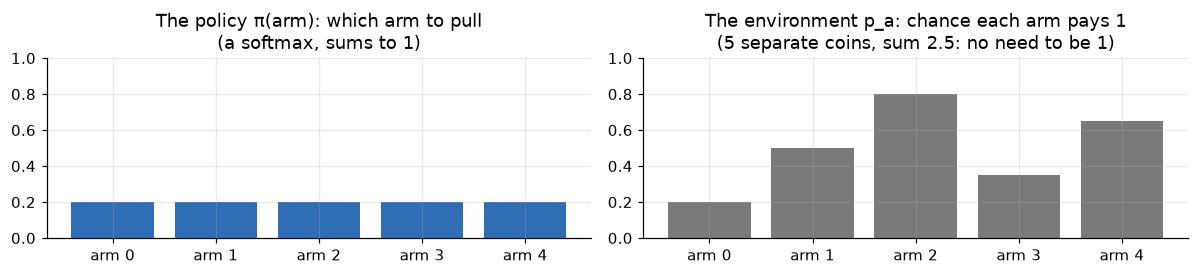

In [3]:
TRUE_P = torch.tensor([0.20, 0.50, 0.80, 0.35, 0.65])  # hidden from the learner; arm 2 is best
N_ARMS = len(TRUE_P)


def pull(actions):
    # The environment: arm indices in, 0/1 rewards out. A black box, like an answer checker.
    return torch.bernoulli(TRUE_P[actions])


def sample(logits, n):
    # Draw n arms from the policy, and return log π(arm) for each (differentiable).
    probs = torch.softmax(logits, dim=-1)
    actions = torch.multinomial(probs.detach(), n, replacement=True)
    log_probs = torch.log_softmax(logits, dim=-1)[actions]
    return actions, log_probs


def expected_reward(logits):
    # J = Σ_a π(a) p_a. We can only compute this because we secretly know TRUE_P.
    return (torch.softmax(logits, dim=-1) * TRUE_P).sum()


start_policy = torch.softmax(torch.zeros(N_ARMS), -1)
fig, axes = plt.subplots(1, 2, figsize=(11, 2.6))
axes[0].bar(range(N_ARMS), start_policy, color=viz.PALETTE["blue"])
axes[0].set_title(f"The policy π(arm): which arm to pull\n(a softmax, sums to {start_policy.sum():.0f})")
axes[1].bar(range(N_ARMS), TRUE_P, color=viz.PALETTE["gray"])
axes[1].set_title(f"The environment p_a: chance each arm pays 1\n(5 separate coins, sum {TRUE_P.sum():.1f}: no need to be 1)")
for ax in axes:
    ax.set_xticks(range(N_ARMS)), ax.set_xticklabels([f"arm {i}" for i in range(N_ARMS)]), ax.set_ylim(0, 1)
fig.tight_layout(), plt.show();

**Two different sets of numbers, don't mix them up.** The softmax belongs to the *policy* (left): it's a probability distribution over *which arm to pull*, so it sums to 1. `TRUE_P` belongs to the *environment* (right): each arm is its own independent coin, and `TRUE_P[a]` is that coin's chance of paying 1. Nothing forces those to sum to 1, just like five different slot machines can each pay out 80% of the time.

For an LLM it's the same split: the model's softmax decides *which completion to write*; whether that completion is correct is a separate fact about the world, checked by the reward function.

## The gradient we want, and why we can't just compute it

We want to maximize the expected reward $J(\theta) = \sum_a \pi_\theta(a)\, p_a$. Here autograd can give us the exact gradient, because we know $p$. **For an LLM you can't**: there are astronomically many completions to sum over, and the reward is a Python function you can only call on completions you've actually generated.

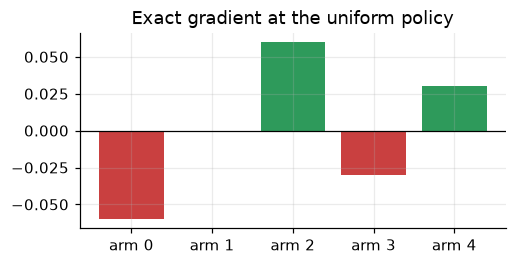

In [4]:
logits = torch.zeros(N_ARMS, requires_grad=True)  # start uniform: every arm has probability 0.2
expected_reward(logits).backward()
exact_grad = logits.grad.clone()

plt.figure(figsize=(5, 2.3))
plt.bar(range(N_ARMS), exact_grad, color=[viz.PALETTE["green"] if g > 0 else viz.PALETTE["red"] for g in exact_grad])
plt.axhline(0, color="black", lw=0.8)
plt.xticks(range(N_ARMS), [f"arm {i}" for i in range(N_ARMS)])
plt.title("Exact gradient at the uniform policy"), plt.show();

**Notice:** arms that pay better than the current average ($J = 0.5$) get pushed up, worse ones get pushed down, and arm 1 (exactly average) gets zero. For a softmax, $\partial J/\partial\theta_a = \pi(a)\,(p_a - J)$. *"Better than average"* is the idea of an **advantage**, and it's coming back in every notebook.

## The trick: REINFORCE (the log-derivative trick)

$$
\nabla J = \sum_a p_a\, \nabla \pi(a) = \sum_a p_a\, \pi(a)\, \nabla \log \pi(a)
= \mathbb{E}_{a\sim\pi}\big[\, p_a\, \nabla \log \pi(a) \big]
\approx \frac1N \sum_i r_i\, \nabla \log \pi(a_i)
$$

The middle step uses $\nabla \pi = \pi \nabla \log \pi$. The result is an *average over samples*, so it only needs things we have: samples, their rewards, and the gradient of their log-probabilities. No gradient through the sampling, none through the reward.

In code, you get it by building a **surrogate loss** whose gradient is exactly that, and calling `.backward()`:

In [5]:
def reinforce_loss(log_probs, rewards):
    return -(rewards.detach() * log_probs).mean()


def estimate_grad(n, weight_fn=None, reward_offset=0.0):
    # One REINFORCE gradient estimate from n samples at the uniform policy.
    logits = torch.zeros(N_ARMS, requires_grad=True)
    actions, log_probs = sample(logits, n)
    rewards = pull(actions) + reward_offset
    weights = rewards if weight_fn is None else weight_fn(rewards)
    reinforce_loss(log_probs, weights).backward()
    return -logits.grad  # minus: we want the uphill direction of J

Does it work? Compare estimates from N samples with the exact gradient:

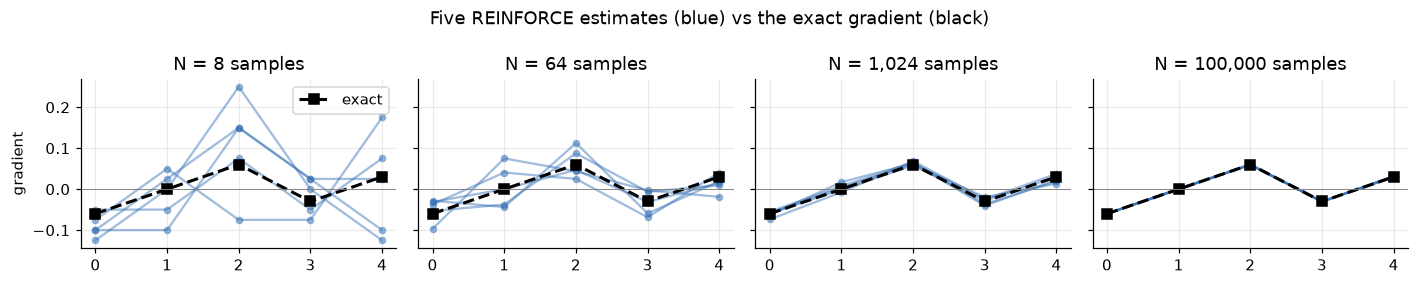

In [6]:
torch.manual_seed(0)
ns = [8, 64, 1024, 100_000]
fig, axes = plt.subplots(1, len(ns), figsize=(13, 2.6), sharey=True)
for ax, n in zip(axes, ns):
    for k in range(5):  # 5 independent estimates
        ax.plot(range(N_ARMS), estimate_grad(n), "o-", color=viz.PALETTE["blue"], alpha=0.45, ms=4)
    ax.plot(range(N_ARMS), exact_grad, "s--", color="black", lw=2, label="exact")
    ax.axhline(0, color="gray", lw=0.6)
    ax.set_title(f"N = {n:,} samples"), ax.set_xticks(range(N_ARMS))
axes[0].legend(), axes[0].set_ylabel("gradient"), fig.suptitle("Five REINFORCE estimates (blue) vs the exact gradient (black)")
fig.tight_layout(), plt.show();

**Notice:** with many samples the estimates land on the exact gradient: the trick is correct. With 8 samples they're all over the place, sometimes even pointing the wrong way for some arms.

That matters because LLM RL lives at small N: GRPO typically samples 4 to 16 completions per prompt, and each one costs a full generation. **Noise (variance) is the central practical problem**, and most of what separates REINFORCE, GRPO and PPO is how they fight it.

## Train it

Plain SGD: sample 16 arms, compute the loss, step. We track the *exact* expected reward to see progress, and the policy's probabilities over time.

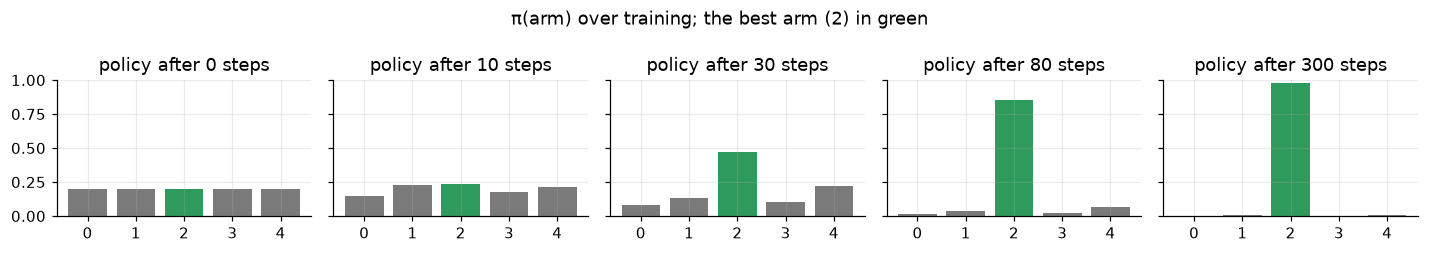

In [7]:
def train(steps=300, batch_size=16, lr=0.5, weight_fn=None, reward_offset=0.0, seed=0, snapshot_at=()):
    torch.manual_seed(seed)
    logits = torch.zeros(N_ARMS, requires_grad=True)
    opt = torch.optim.SGD([logits], lr=lr)
    history, snapshots = [], {}
    for step in range(steps):
        if step in snapshot_at:
            snapshots[step] = torch.softmax(logits, -1).detach().clone()
        actions, log_probs = sample(logits, batch_size)
        rewards = pull(actions) + reward_offset
        weights = rewards if weight_fn is None else weight_fn(rewards)
        loss = reinforce_loss(log_probs, weights)
        opt.zero_grad()
        loss.backward()
        opt.step()
        history.append(expected_reward(logits).item())
    snapshots[steps] = torch.softmax(logits, -1).detach()
    return history, snapshots


history, snaps = train(snapshot_at=(0, 10, 30, 80))
fig, axes = plt.subplots(1, len(snaps), figsize=(13, 2.3), sharey=True)
for ax, (step, p) in zip(axes, snaps.items()):
    ax.bar(range(N_ARMS), p, color=[viz.PALETTE["green"] if i == 2 else viz.PALETTE["gray"] for i in range(N_ARMS)])
    ax.set_title(f"policy after {step} steps"), ax.set_xticks(range(N_ARMS)), ax.set_ylim(0, 1)
fig.suptitle("π(arm) over training; the best arm (2) in green"), fig.tight_layout(), plt.show();

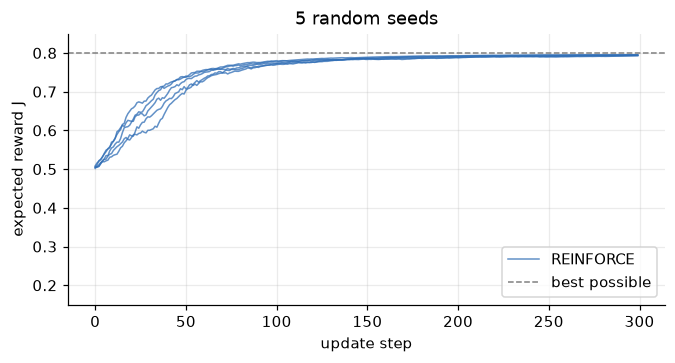

In [8]:
def plot_runs(runs, title):
    plt.figure(figsize=(7, 3.2))
    colors = [viz.PALETTE[c] for c in ("blue", "orange", "green", "purple")]
    for color, (label, histories) in zip(colors, runs.items()):
        for i, h in enumerate(histories):
            plt.plot(h, color=color, alpha=0.75, lw=1, label=label if i == 0 else None)
    plt.axhline(TRUE_P.max(), ls="--", c="gray", lw=1, label="best possible")
    plt.xlabel("update step"), plt.ylabel("expected reward J"), plt.title(title)
    plt.ylim(0.15, 0.85), plt.legend(loc="lower right"), plt.show()


plot_runs({"REINFORCE": [train(seed=s)[0] for s in range(5)]}, "5 random seeds")

## Baselines: the first weapon against noise

An experiment. Give every reward a +5 bonus ("5 points for showing up"). Which arm is best doesn't change at all.

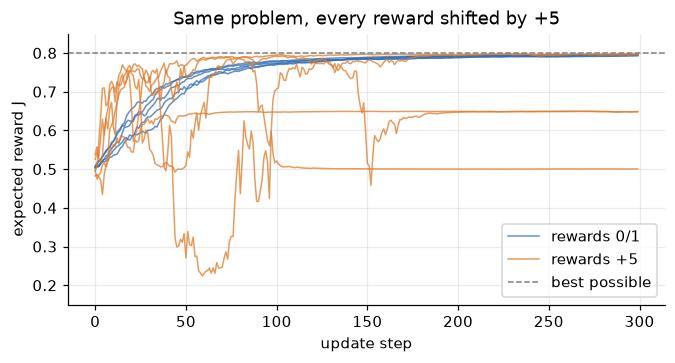

In [9]:
plot_runs({
    "rewards 0/1": [train(seed=s)[0] for s in range(5)],
    "rewards +5": [train(reward_offset=5.0, seed=s)[0] for s in range(5)],
}, "Same problem, every reward shifted by +5")

**Notice:** several +5 runs get stuck on the wrong arm. Now *every* sample has a big positive weight, so whichever arms happen to get sampled get pushed up hard. On average those pushes cancel out to the right direction, but with 16 samples an unlucky early batch boosts a mediocre arm, which then gets sampled more, which boosts it more.

**The fix: subtract a baseline**, and weight each sample by its **advantage** $A_i = r_i - b$ instead of $r_i$. Any $b$ that doesn't depend on the sampled action leaves the average gradient unchanged, because

$$\mathbb{E}_{a\sim\pi}[\, b\, \nabla \log \pi(a)] = b\, \nabla \textstyle\sum_a \pi(a) = b\, \nabla 1 = 0,$$

but it can remove a huge amount of noise. Below-average samples now get pushed *down*, not just less up.

The simplest baseline is the batch's own mean reward. That's exactly what **GRPO** does with a group of completions for the same prompt. GRPO also divides by the standard deviation, which makes the scale of the reward irrelevant too.

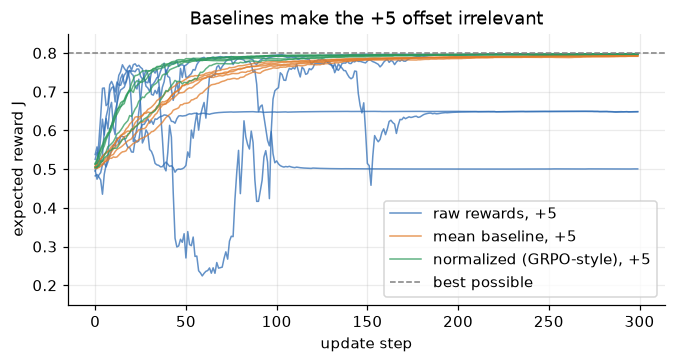

In [10]:
def mean_baseline(rewards):
    return rewards - rewards.mean()


def normalized(rewards):  # GRPO's "group-relative" advantage
    return (rewards - rewards.mean()) / (rewards.std() + 1e-6)


plot_runs({
    "raw rewards, +5": [train(reward_offset=5.0, seed=s)[0] for s in range(5)],
    "mean baseline, +5": [train(reward_offset=5.0, weight_fn=mean_baseline, seed=s)[0] for s in range(5)],
    "normalized (GRPO-style), +5": [train(reward_offset=5.0, weight_fn=normalized, seed=s)[0] for s in range(5)],
}, "Baselines make the +5 offset irrelevant")

Here's the noise reduction directly. For each method, 2,000 independent 16-sample gradient estimates, scored by their cosine similarity with the exact gradient (1 = points exactly the right way, 0 = unrelated, negative = wrong way):

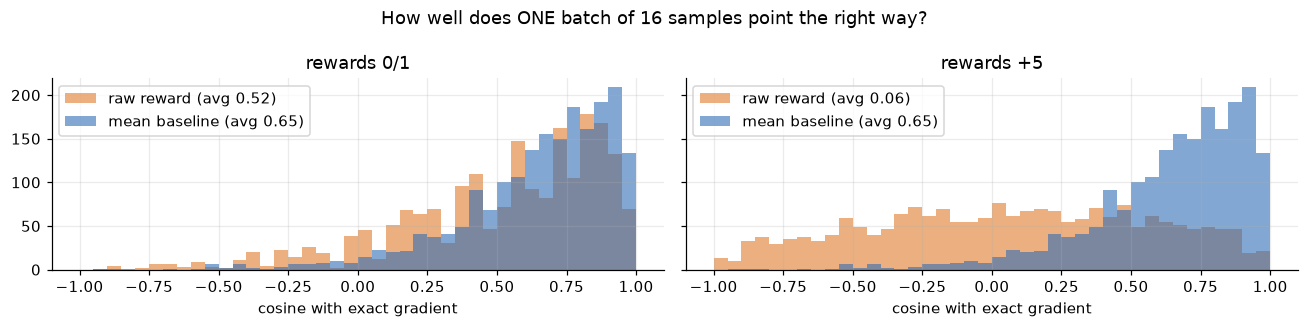

In [11]:
def cosines(weight_fn, offset, trials=2000):
    torch.manual_seed(0)
    g = torch.stack([estimate_grad(16, weight_fn, offset) for _ in range(trials)])
    return torch.nn.functional.cosine_similarity(g, exact_grad.expand_as(g), dim=1).numpy()


bins = np.linspace(-1, 1, 41)
fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharey=True)
for ax, offset in zip(axes, [0.0, 5.0]):
    for label, fn, c in [("raw reward", None, "orange"), ("mean baseline", mean_baseline, "blue")]:
        cs = cosines(fn, offset)
        ax.hist(cs, bins=bins, alpha=0.6, color=viz.PALETTE[c], label=f"{label} (avg {cs.mean():.2f})")
    ax.set_title(f"rewards {'0/1' if offset == 0 else '+5'}"), ax.set_xlabel("cosine with exact gradient"), ax.legend()
fig.suptitle("How well does ONE batch of 16 samples point the right way?"), fig.tight_layout(), plt.show();

**Notice:** with the +5 offset, raw-reward estimates are close to random directions (average cosine near 0). With the baseline, the offset makes no difference at all.

One more thing to see before moving on: **if every sample in a batch gets the same reward, every advantage is 0 and nothing is learned.** For GRPO that means a prompt the model always gets right (or always gets wrong) is wasted compute. That's why task difficulty matters, which notebook 2 measures.

## What carries over to LLMs

| Here | With an LLM (next notebooks) |
|---|---|
| `sample(logits, n)` | `model.generate(...)`, then a forward pass to get each token's log-prob |
| log π(arm) | Σ over completion tokens of log π(token \| everything before it) |
| `pull(arm)` | check the answer: 1 if `<answer>…</answer>` holds the right number |
| a batch of arms | a group of completions for the same prompt |
| mean / normalized baseline | GRPO's group-relative advantage |
| `-(A * log_prob).mean()` | the same loss, every token of a completion weighted by its advantage |

What the real algorithms add on top:
- **A KL leash** to the starting model, so the policy can't drift into weird text that happens to score well (REINFORCE notebook).
- **Reusing samples** for several gradient steps, made safe by **clipping** a probability ratio (GRPO notebook).
- **A learned critic** that predicts the reward token by token, so each token gets its own advantage (PPO notebook).
- **No sampling at all**: learning from fixed preference pairs (DPO notebook).

## Further reading

- R. J. Williams (1992), [Simple statistical gradient-following algorithms for connectionist reinforcement learning](https://link.springer.com/article/10.1007/BF00992696): the original REINFORCE paper.
- R. S. Sutton & A. G. Barto, [Reinforcement Learning: An Introduction](http://incompleteideas.net/book/the-book-2nd.html), chapter 13 (policy gradient methods). Free online.